In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
import os
os.listdir()
os.listdir()

['.ipynb_checkpoints', 'StudentsPerformance.csv', 'task-1.ipynb']

In [10]:
# Load Dataset

In [8]:
df = pd.read_csv("StudentsPerformance.csv")

In [ ]:
########## View the dataset

In [11]:
df.head()


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [ ]:
### Understand the dataset

In [12]:
df.shape

(1000, 8)

In [13]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [25]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [15]:
####  Data Cleaning

In [16]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [17]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [18]:
df.duplicated().sum()

0

In [19]:
df.drop_duplicates(inplace=True)

In [20]:
######## Analyze the Data

In [ ]:
### Average Scores

In [22]:
df["math score"].mean()

66.089

In [23]:
df["reading score"].mean()

69.169

In [24]:
df["writing score"].mean()

68.054

In [26]:
######### Highest and Lowest Score

In [27]:
df["math score"].max()

100

In [28]:
df["math score"].min()

0

In [30]:
######Count Male and Female Students

In [31]:
df["gender"].value_counts()

female    518
male      482
Name: gender, dtype: int64

In [32]:
##### Average Math Score by Gender
df.groupby("gender")["math score"].mean()

gender
female    63.633205
male      68.728216
Name: math score, dtype: float64

In [35]:

####  Average Writing Score by gender
df.groupby("gender")["writing score"].mean()

gender
female    72.467181
male      63.311203
Name: writing score, dtype: float64

In [36]:
####  Average Reading Score gender
df.groupby("gender")["reading score"].mean()


gender
female    72.608108
male      65.473029
Name: reading score, dtype: float64

In [37]:
df["test preparation course"].value_counts()

none         642
completed    358
Name: test preparation course, dtype: int64

In [38]:
############ visualizaton ##########

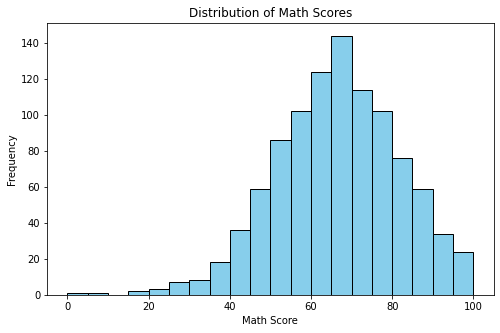

In [39]:
###### histogram
plt.figure(figsize=(8,5))
plt.hist(df["math score"], bins=20, color="skyblue", edgecolor="black")
plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Frequency")
plt.show()

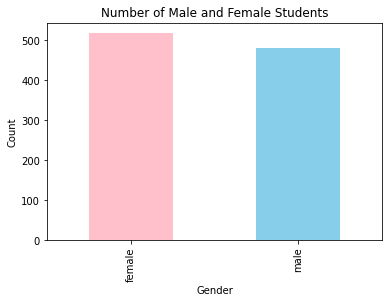

In [40]:
########## Barchat
df["gender"].value_counts().plot(kind="bar", color=["pink","skyblue"])
plt.title("Number of Male and Female Students")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

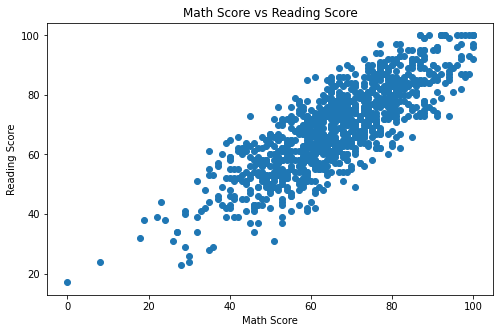

In [41]:
########## scatter plot
plt.figure(figsize=(8,5))
plt.scatter(df["math score"], df["reading score"])
plt.xlabel("Math Score")
plt.ylabel("Reading Score")
plt.title("Math Score vs Reading Score")
plt.show()

In [42]:
########### correlation matrix
corr = df[["math score","reading score","writing score"]].corr()

corr

,math score,reading score,writing score
math score,1.000000,0.817580,0.802642
reading score,0.817580,1.000000,0.954598
writing score,0.802642,0.954598,1.000000


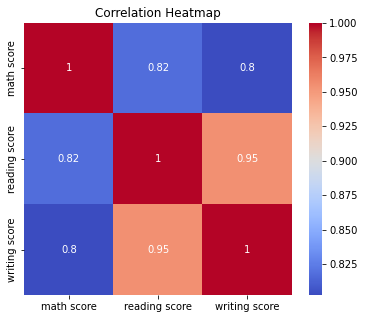

In [43]:
########### heat map
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()